In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
from scipy.stats import crystalball
import scipy.special as sc
from iminuit import cost, Minuit
from numba_stats import crystalball, norm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][2]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_single):
    NTD_data = []
    no_NTD_data = []

    for i in range(len(dataframe_single)):
        if (dataframe_single.iloc[i,10][0] in dataframe_single.iloc[i,17]) or (dataframe_single.iloc[i,10][1] in dataframe_single.iloc[i,17]) or (dataframe_single.iloc[i,10][2] in dataframe_single.iloc[i,17]):
                NTD_data.append(i) 
        else:
            no_NTD_data.append(i) 

    NTD_dataframe = dataframe_single[dataframe_single.index.isin(NTD_data)]
    NTD_dataframe =NTD_dataframe.reset_index(drop=True)

    no_NTD_dataframe = dataframe_single[dataframe_single.index.isin(no_NTD_data)]
    no_NTD_dataframe=no_NTD_dataframe.reset_index(drop=True)
    
    return NTD_dataframe, no_NTD_dataframe

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0] + dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [ ]:
def ChannelRemoval(dataframe):
    df = pd.read_csv('InvalidChannels/M3SE2104_InvalidChannelList.csv', sep=',')
    datasetlist = np.arange(3801, 3829)

    # Create a dictionary mapping each dataset to its channel list
    channel_map = df.groupby('Dataset')['Channels'].apply(list).to_dict()

    channel = []

    # Loop through the filtered datasets in dataframe_single
    for i in datasetlist:
        # Get the channel list for the dataset from the pre-built dictionary
        channel_list = channel_map.get(i, [])
        
        # Filter only rows in dataframe_single where the 'Dataset' equals the current dataset
        relevant_rows = dataframe[dataframe['Dataset'] == i]
        
        # Check for channel matches using vectorized apply with any()
        matches = relevant_rows.index[
            relevant_rows.iloc[:, 10].apply(lambda x: any(ch in channel_list for ch in x))
        ].tolist()
        
        # Add matching indices to the channel list
        channel.extend(matches)
        
    dataframe_reduced = dataframe.drop(channel)
    dataframe_reduced=dataframe_reduced.reset_index(drop=True)
        
    return dataframe_reduced
    

In [29]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)
dataframe_reduced_single = ChannelRemoval(dataframe_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_56795/3449785898.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_56795/3158374240.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_56795/3158374240.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [30]:
NTD_single, no_NTD_single = NTD_Sort(dataframe_reduced_single)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_single)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_single)

NTD_events = pd.concat([FC_NTD, FN_NTD, FF_NTD, FE_NTD])
NonNTDevents = pd.concat([FC, CE, CE_NTD, NC, NC_NTD, FN, NE, NE_NTD, FF, CC, CC_NTD, EE, EE_NTD, NN, NN_NTD, FE])

CEmerged = pd.concat([CE, CE_NTD])
NCmerged = pd.concat([NC, NC_NTD])
NEmerged = pd.concat([NE, NE_NTD])
CCmerged = pd.concat([CC, CC_NTD])
EEmerged = pd.concat([EE, EE_NTD])
NNmerged = pd.concat([NN, NN_NTD])

In [31]:
def Double_Gaussian(x, mu, mu2, sigma, A, f, d):
    E0 = min(x)
    E1=max(x)
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-f-d)*norm.pdf(x,mu, sigma)+d*norm.pdf(x,mu2, sigma)+f*p

def Chi2(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = Double_Gaussian(filtered_bin_centers, *arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Residual_Plot(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = Double_Gaussian(filtered_bin_centers, *arr)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

def Minimizer(data, title, initial_parms, bin_num):
    c = cost.UnbinnedNLL(data, Double_Gaussian)

    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)

    m = Minuit(c,*initial_parms)
    m.limits["f", "d"] = (0, 1)
    m.limits["mu", 'mu2', 'sigma'] = (0, None)
    m.limits["A"] = (-bound_A, bound_A)
    m.migrad()
    m.hesse()

    x_values = np.linspace(min(data), max(data), 1000)
    bin_width = (max(data) - min(data))/bin_num

    fig = plt.figure()
    ax=fig.add_axes((.1,.3,.8,.6))
    
    props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
    text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(data, m.values, bin_num), decimals=2)) +'/' +str(bin_num - (Double_Gaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num - (Double_Gaussian.__code__.co_argcount -1),Chi2(data, m.values, bin_num)), ),
        'Entries: ' + (str(len(data))),
        r'$\mu=$ ' + str(np.round(m.values[0], decimals = 2) ) + '+-'+ str(np.round(m.errors[0], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(m.values[1], decimals=2) ) + '+-'+ str(np.round(m.errors[1], decimals=2) ),
        r'$\sigma=$ ' + str(np.round(m.values[2], decimals = 2) ) + '+-'+ str(np.round(m.errors[2], decimals = 2) ),
        #r'$\sigma_2=$ ' + str(np.round(m.values[3], decimals = 2) ) + '+-'+ str(np.round(m.errors[3], decimals = 2) ),
        r'$A=$ ' + str(np.format_float_scientific(m.values[3], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[3], precision = 2) ),
        r'$f=$ ' + str(np.format_float_scientific(m.values[4], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[4], precision = 2) ),
        r'$d=$ ' + str(np.format_float_scientific(m.values[5], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[5], precision = 2) )
        ))
    
    mu, mu2,sigma, A,f,d = m.values
    muerr, mu2err,sigmaerr, Aerr,ferr,derr = m.errors

    ax.hist(data, bins = bin_num, histtype="step");
    ax.plot(x_values, Double_Gaussian(x_values,*m.values)*len(data)*bin_width,label='Fitted PDF', color='#000272')
    ax.plot(x_values, (1-f-d)*norm.pdf(x_values,mu, sigma)*len(data)*bin_width, label='Primary Gaussian', linestyle='--', color='#A72693')
    ax.plot(x_values, f*(1+A*(x_values-Ec))/(E1-E0)*len(data)*bin_width, label='Linear Bckg', linestyle='--', color='#BD512F')
    ax.plot(x_values, d*norm.pdf(x_values,mu2, sigma)*len(data)*bin_width, label='Secondary Gaussian', linestyle='--', color='#02383C')
    ax.legend(loc='upper right')
    ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
    ax.set_title(title)

    ax2=fig.add_axes((.1,.08,.8,.2))        
    ax2.errorbar(Residual_Plot(data, m.values,bin_num)[0],Residual_Plot(data, m.values, bin_num)[1], fmt='o',markersize=4)
    ax2.axhline(0, linestyle='--', color='crimson')
    
    return mu, muerr, sigma, sigmaerr, Chi2(data, m.values, bin_num)

def MinimizerTopologies(data, topologies, initial_parms, wid, height, figwidth, figheight):
    fitarr = []
    errorarr = []
    PDFs = []
    guass1 = []
    guass2 = []
    linear = []
    xvals = []
    bin_num = []
    bin_width = []

    for i in range(len(data)):
        E0 = min(data[i])
        E1 = max(data[i])
        Ec = (E0+E1)/2
        bound_A = 1/(Ec-E0)
        c = cost.UnbinnedNLL(data[i], Double_Gaussian)
        m = Minuit(c,*initial_parms[i])
        m.limits["f", "d"] = (0, 1)
        m.limits["mu", 'mu2', 'sigma'] = (0, None)
        m.limits["A"] = (-bound_A, bound_A)
        m.migrad()
        m.hesse()
        
        fitarr.append(m.values)
        errorarr.append(m.errors)
        x_values = np.linspace(min(data[i]), max(data[i]), 1000)
        xvals.append(x_values)
        bin_num.append(int(E1-E0))
        
        bin_width.append((E1-E0)/(int(E1-E0)))

    chisq = []
    pvals = []
    means = []
    means2 = []
    sigmas = []
    # sigmas2 = []
    A = []
    f = []
    d = []

    meanserr = []
    means2err = []
    sigmaserr = []
    # sigmas2err = []
    Aerr= []
    ferr = []
    derr = []
        
    for i in range(len(fitarr)):
        E0 = min(data[i])
        E1 = max(data[i])
        PDFs.append(Double_Gaussian(xvals[i],*fitarr[i])*len(data[i])*bin_width[i])
        guass1.append((1-fitarr[i][4]-fitarr[i][5])*norm.pdf(xvals[i],fitarr[i][0], fitarr[i][2])*len(data[i])*bin_width[i])
        guass2.append((fitarr[i][5])*norm.pdf(xvals[i],fitarr[i][1], fitarr[i][2])*len(data[i])*bin_width[i])
        linear.append(fitarr[i][4]*(1+fitarr[i][3]*(xvals[i]-Ec))/(E1-E0)*len(data[i])*bin_width[i])
        chisq.append(Chi2(data[i], fitarr[i], bin_num[i]))
        pvals.append(PValue(bin_num[i]-(Double_Gaussian.__code__.co_argcount -1), chisq[i]))
        
        means.append(fitarr[i][0])
        means2.append(fitarr[i][1])
        sigmas.append(fitarr[i][2])
        # sigmas2.append(fitarr[i][3])
        A.append(fitarr[i][3])
        f.append(fitarr[i][4])
        d.append(fitarr[i][5])
        
        meanserr.append(errorarr[i][0])
        means2err.append(errorarr[i][1])
        sigmaserr.append(errorarr[i][2])
        # sigmas2err.append(errorarr[i][3])
        Aerr.append(errorarr[i][3])
        ferr.append(errorarr[i][4])
        derr.append(errorarr[i][5])
        
        
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': data,
        'X-axis': xvals,
        'Fit': PDFs,
        'Guass1': guass1,
        'Guass2': guass2,
        'Linear': linear,
        'Means': means,
        'Means2': means2,
        'Sigmas': sigmas,
        # 'Sigmas2': sigmas2,
        'A': A,
        'f': f,
        'd': d, 
        'Chi2': chisq,
        'p-value': pvals, 
        'Meanserr': meanserr,
        'Means2err': means2err,
        'Sigmaserr': sigmaserr,
        # 'Sigmas2err': sigmas2err,
        'Aerr': Aerr,
        'ferr': ferr,
        'derr': derr,}

    df = pd.DataFrame(data)
        
    fig, axs = plt.subplots(wid, height, figsize=(figwidth, figheight))
    props = dict(boxstyle='round', facecolor='whitesmoke')
    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) +'/' +str(df['Bin Num'][i] - (Double_Gaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
        'Entries: ' + (str(len(df['Histogram Data'][i]))),
        r'$\mu=$ ' + str(np.round(df['Means'][i], decimals = 2) ) + '+-'+ str(np.round(df['Meanserr'][i], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(df['Means2'][i], decimals=2) ) + '+-'+ str(np.round(df['Means2err'][i], decimals=2) ),
        r'$\sigma=$ ' + str(np.round(df['Sigmas'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmaserr'][i], decimals = 2) ),
        # r'$\sigma_2=$ ' + str(np.round(df['Sigmas2'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmas2err'][i], decimals = 2) ),
        r'$A=$ ' + str(np.format_float_scientific(df['A'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['Aerr'][i], precision = 2) ),
        r'$f=$ ' + str(np.format_float_scientific(df['f'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['ferr'][i], precision = 2) ),
        r'$d=$ ' + str(np.format_float_scientific(df['d'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['derr'][i], precision = 2) )
        ))
            
            ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], histtype="step")
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='#000272')
            ax.plot(df['X-axis'][i], df['Guass1'][i], label='Primary Gaussian', linestyle='--', color='#A72693')
            ax.plot(df['X-axis'][i], df['Guass2'][i], label='Secondary Gaussian', linestyle='--', color='#02383C')
            ax.plot(df['X-axis'][i], df['Linear'][i], label='Linear Background', linestyle='--', color='#BD512F')
            ax.set_title(df["Topologies"][i])
            ax.legend(loc='upper right')
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[0],Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()
    
    return df

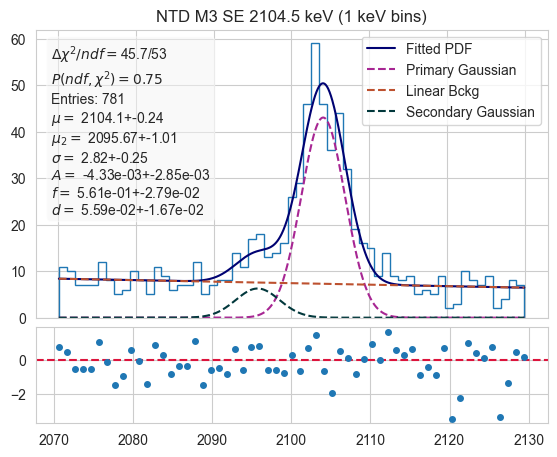

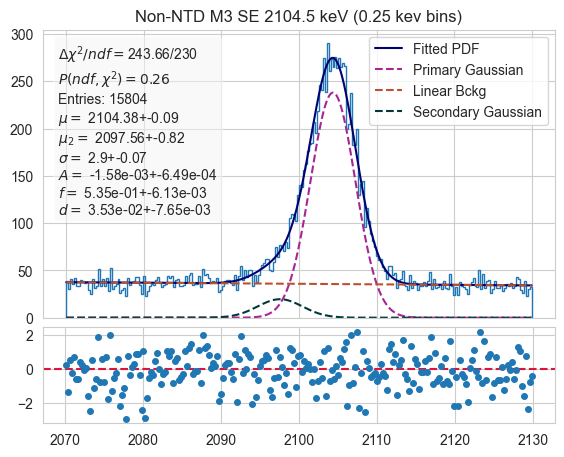

In [32]:
NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_events)
NTDmu, NTDmu_err, NTDsigma, NTDsigmaerr, NTDchi2 = Minimizer(NTD_2100, 'NTD M3 SE 2104.5 keV (1 keV bins)', [2104.4138503844847, 2090, 2.3, 1.71e-3, 0.5, 0.1], int(max(NTD_2100)-min(NTD_2100)))

NonNTD_2100, NonNTD_511 = PrimarySecondarySplit(NonNTDevents)

nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigmaerr, nonNTDchi2 = Minimizer(NonNTD_2100, 'Non-NTD M3 SE 2104.5 keV (0.25 kev bins)', [2104.4138503844847, 2095, 3.04, 1.71e-3, 0.5, 0.1], 4*int(max(NonNTD_2100)-min(NonNTD_2100)))

In [110]:
print(2104.38-2104.5)

-0.11999999999989086


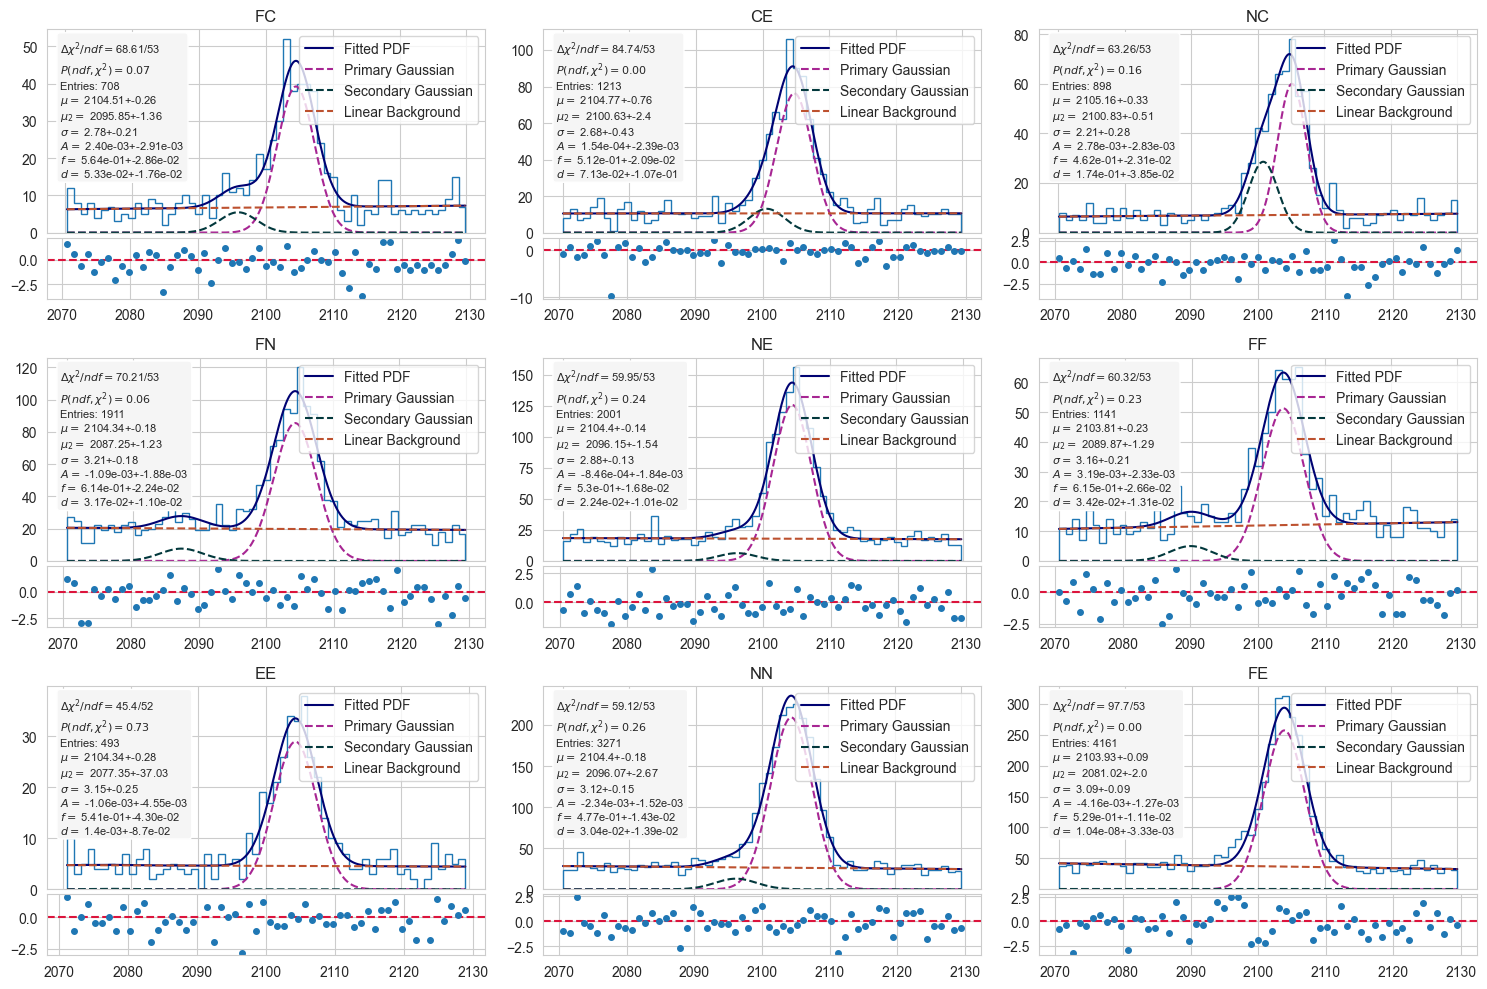

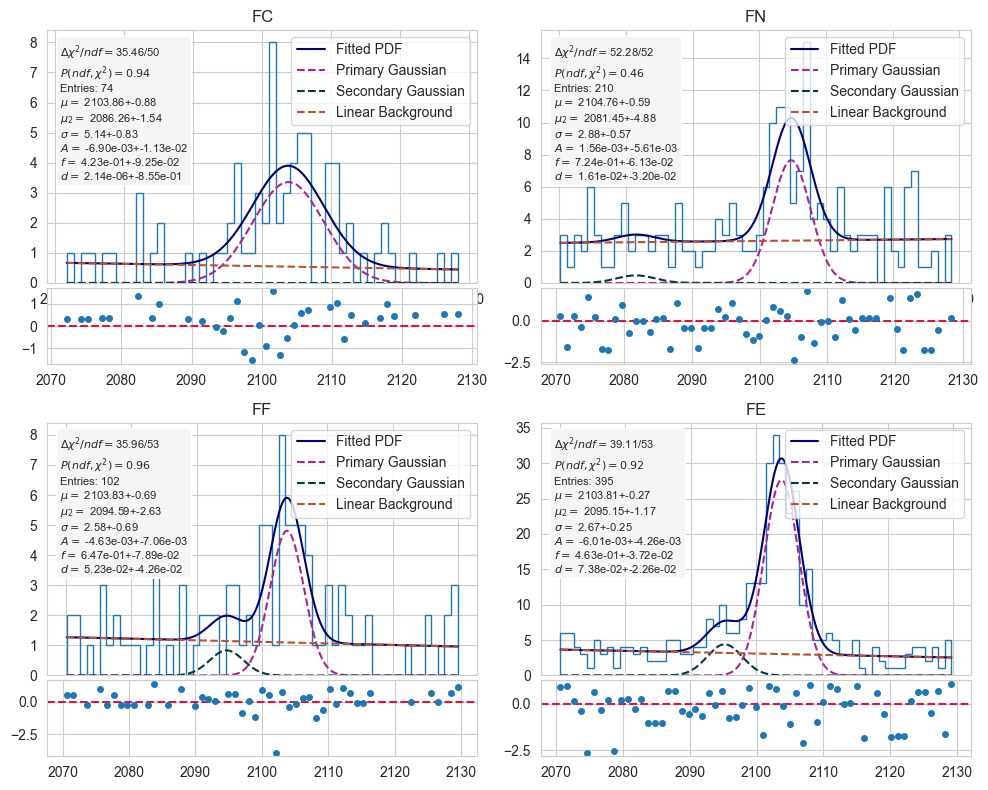

In [105]:
FC_2100, FC_511 = PrimarySecondarySplit(FC)
CE_2100, CE_511 = PrimarySecondarySplit(CEmerged)
NC_2100, NC_511 = PrimarySecondarySplit(NCmerged)
FN_2100, FN_511 = PrimarySecondarySplit(FN)
NE_2100, NE_511 = PrimarySecondarySplit(NEmerged)
FF_2100, FF_511 = PrimarySecondarySplit(FF)
# CC_2100, CC_511 = PrimarySecondarySplit(CC) not enough events to fit anything
EE_2100, EE_511 = PrimarySecondarySplit(EEmerged)
NN_2100, NN_511 = PrimarySecondarySplit(NNmerged)
FE_2100, FE_511 = PrimarySecondarySplit(FE)


FC_2100NTD, FC_511NTD = PrimarySecondarySplit(FC_NTD)
FN_2100NTD, FN_511NTD = PrimarySecondarySplit(FN_NTD)
FF_2100NTD, FF_511NTD = PrimarySecondarySplit(FF_NTD)
FE_2100NTD, FE_511NTD = PrimarySecondarySplit(FE_NTD)


FC_initial_2100 = [2.10420591e+3, 2095, 3.25076564, 6.62930626/3.57543524e+2, 0.1, 0.1]
CE_initial_2100 = [2.10431458e+3,  2095, 2, 6.95816602/5.28868090e+2, 0.3, 0.3]
NC_initial_2100 = [2.10408443e+3, 2095, 2.9, 4.64167835/4.14757903e+2, 0.3, 0.3]
FN_initial_2100 = [2.10446511e+3, 2095, 2.9, 1.42947997e+1/5.31468025e+2, 0.3, 0.3]
NE_initial_2100 = [2.10428559e+3, 2095, 2.9, 1.18973642e+1/7.92020460e+2, 0.5, 0.1]
FF_initial_2100 = [2.10384220e+3, 2095, 2.94879678, 7.39805739/2.92487903e+2, 0.3, 0.2]
EE_initial_2100 = [2.10429581e+3, 2095, 3.18361783, 3.07702572/1.82678290e+2, 0.1, 0.2]
NN_initial_2100 = [2.10440454e+3, 2095, 2.9, 1.79403180/1.31148969e+2, 0.5, 0.3]
FE_initial_2100 = [2.10397686e+3, 2095, 3.00489800, 2.50052853/1.66988732e+2, 0.1, 0.3]

FC_initial_2100NTD = [2.10342955e+03, 2095, 3.63130053e+00, 2.62135783e+00/8.11034707e+2, 0.1, 0.1]
FN_initial_2100NTD = [ 2.10456843e+03, 2095, 3.23366653e+00, 2.06372015e+00/1.22944665e+02,0.2, 0.3]
FF_initial_2100NTD = [2.10510104e+03,  2095, 1.53677534e+00, 4.18592268e+00/1.86227185e+02,0.5, 0.3]
FE_initial_2100NTD = [2.10431740e+03, 2095, 2.64476582e+00, 4.23619557e+00/3.38125388e+02,0.3, 0.3]

hist_data = [FC_2100, CE_2100, NC_2100, FN_2100, NE_2100, FF_2100, EE_2100, NN_2100, FE_2100]
initial_parms = [FC_initial_2100, CE_initial_2100, NC_initial_2100, FN_initial_2100, NE_initial_2100, FF_initial_2100, EE_initial_2100, NN_initial_2100, FE_initial_2100]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

df = MinimizerTopologies(hist_data, topologies, initial_parms, 3,3, 15, 10)

hist_dataNTD = [FC_2100NTD, FN_2100NTD, FF_2100NTD, FE_2100NTD]
initial_parmsNTD = [FC_initial_2100NTD, FN_initial_2100NTD, FF_initial_2100NTD, FE_initial_2100NTD]


dfNTD = MinimizerTopologies(hist_dataNTD, ['FC', 'FN', 'FF', 'FE'], initial_parmsNTD, 2,2, 10, 8)



In [89]:
def ExpectedVals(total_dataframe, dataframe):
        weights = [(((len(total_dataframe[total_dataframe['Dataset']==3801]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3801]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3802]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3802]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3803]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3803]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3804]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3804]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3805]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3805]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3806]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3806]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3807]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3807]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3808]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3808]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3809]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3809]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3810]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3810]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3811]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3811]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3812]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3812]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3813]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3813]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3814]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3814]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3815]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3815]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3816]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3816]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3817]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3817]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3818]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3818]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3819]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3819]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3820]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3820]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3821]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3821]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3822]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3822]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3823]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3823]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3824]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3824]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3825]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3825]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3826]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3826]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3827]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3827]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3828]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3828]))/len(dataframe))*100),
                   ]
        
        df_bias = pd.read_csv('Dataset-Info-ResBias/M3SE2104_bias_all.txt', sep=',', names=['Dataset', 'Bias', 'Bias_err'], header=None)
        df_res = pd.read_csv('Dataset-Info-ResBias/M3SE2104_reso_all.txt', sep=',', names=['Dataset', 'Res', 'Res_err'], header=None)
        
        mean_bias = 0
        sigma_res = 0
        
        for i in range(len(weights)):
                mean_bias += weights[i]*df_bias.iloc[i+1,1]
                sigma_res += weights[i]*df_res.iloc[i+1,1]
                
        average_means_bias = mean_bias/sum(weights)
        average_sigma_res = sigma_res/sum(weights)
        
        mean_bias_err = 0
        sigma_res_err = 0
        
        for i in range(len(weights)):
                mean_bias_err += (weights[i]*df_bias.iloc[i+1,2])**2
                sigma_res_err += (weights[i]*df_res.iloc[i+1,2])**2
        
        actual_mean_err = 1/sum(weights)*np.sqrt(mean_bias_err)
        actual_sigma_err = 1/sum(weights)*np.sqrt(sigma_res_err)
        
        
        return average_means_bias, (average_sigma_res/2.355), actual_mean_err, actual_sigma_err*(1/2.355)

In [91]:
mean_bias, sigma, meanerr, sigmaerr = ExpectedVals(dataframe_reduced_single, dataframe_reduced_single)

Text(0, 0.5, '$E_{reconstructed}-2104.5$ (keV)')

<Figure size 640x480 with 0 Axes>

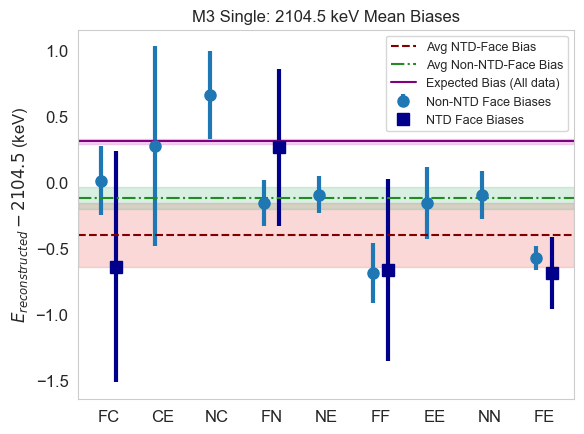

In [92]:
from matplotlib.transforms import Affine2D
plt.figure()
topologiesNTD = ['FC','FN','FF','FE']

topologiesNonNTD = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.14, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.14, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, df['Means']-2104.5, yerr=df['Meanserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Biases')
ax.errorbar(topologiesNTD, dfNTD['Means']-2104.5, yerr=dfNTD['Meanserr'], transform=trans2, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Biases')

ax.axhspan(NTDmu-2104.5 +NTDmu_err, NTDmu-2104.5 -NTDmu_err, color='lightcoral', alpha=0.3)
ax.axhline(NTDmu-2104.5, color='maroon', linestyle='--', label='Avg NTD-Face Bias')

ax.axhspan(nonNTDmu-2104.5-nonNTDmu_err, nonNTDmu-2104.5+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDmu-2104.5, color='forestgreen', linestyle='-.', label='Avg Non-NTD-Face Bias')

plt.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
plt.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias (All data)')

plt.legend(loc='upper right',fontsize=9)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Single: 2104.5 keV Mean Biases')
plt.ylabel(r'$E_{reconstructed}-2104.5$ (keV)', fontsize=12)

Text(0.5, 1.0, 'M3 Single: 2104.5 keV Sigmas')

<Figure size 640x480 with 0 Axes>

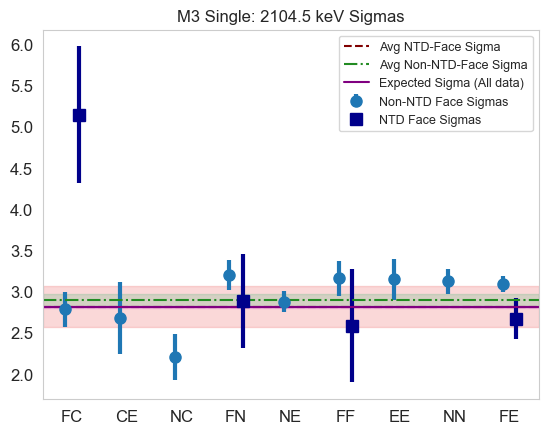

In [98]:
plt.figure()
topologiesNTD = ['FC','FN','FF','FE']

topologiesNonNTD = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.12, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.125, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, df['Sigmas'], yerr=df['Sigmaserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Sigmas')
ax.errorbar(topologiesNTD, dfNTD['Sigmas'], yerr=dfNTD['Sigmaserr'], transform=trans2, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Sigmas')

ax.axhspan(NTDsigma +NTDsigmaerr, NTDsigma -NTDsigmaerr, color='lightcoral', alpha=0.3)
ax.axhline(NTDsigma, color='maroon', linestyle='--', label='Avg NTD-Face Sigma')

ax.axhspan(nonNTDsigma-nonNTDsigmaerr, nonNTDsigma+nonNTDsigmaerr, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Avg Non-NTD-Face Sigma')

plt.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
plt.axhline(sigma, color='purple', linestyle='-', label='Expected Sigma (All data)')

plt.legend(loc='upper right',fontsize=9)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Single: 2104.5 keV Sigmas')

In [113]:
# print(dfNTD['Means']-2104.5)
# print(dfNTD['Meanserr'])

print(dfNTD['Sigmas'])
print(dfNTD['Sigmaserr'])

0    5.142954
1    2.882805
2    2.584637
3    2.669775
Name: Sigmas, dtype: float64
0    0.829383
1    0.567868
2    0.686909
3    0.248576
Name: Sigmaserr, dtype: float64
